# Introduction

In this project, you will build a neural network of your own design to evaluate the CIFAR-10 dataset.
Our target accuracy is 70%, but any accuracy over 50% is a great start.
Some of the benchmark results on CIFAR-10 include:

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

Research with this dataset is ongoing. Notably, many of these networks are quite large and quite expensive to train. 

## Imports

In [1]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

Specify your transforms as a list first.
The transforms module is already loaded as `transforms`.

CIFAR-10 is fortunately included in the torchvision module.
Then, you can create your dataset using the `CIFAR10` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/docs/stable/torchvision/datasets.html#cifar)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [2]:
# Define transforms
train_transform = transforms.Compose(
    [
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomCrop(32, padding=4),
     transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]
)

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 64
# Create training set and define training dataloader
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,shuffle=True, num_workers=4)

# Create test set and define test dataloader
testset = torchvision.datasets.CIFAR10(root='./data', train=False,download=True, transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,shuffle=False, num_workers=4)

# The 10 classes in the dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

/home/karrot/Documents/image-classifier/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [21]:
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])
    
        image = images[i].numpy()
        plt.imshow(image.T)
        plt.show()

bird


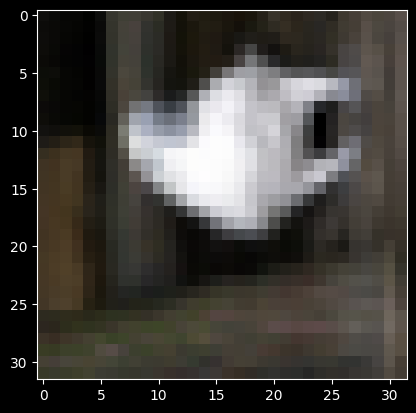

dog


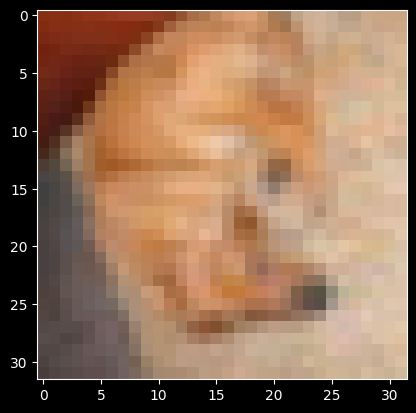

deer


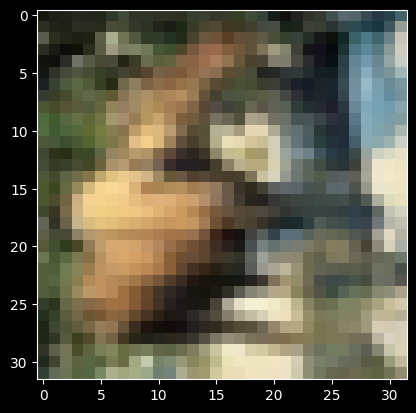

deer


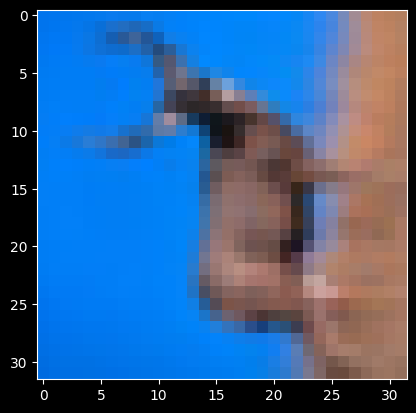

plane


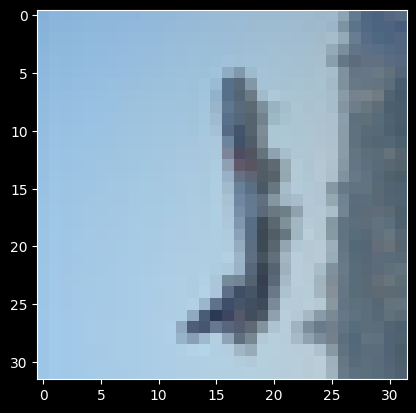

In [24]:
# Explore data
show5(trainloader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset. 
Feel free to construct a model of any architecture – feedforward, convolutional, or even something more advanced!

In [3]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.2)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.conv3 = nn.Conv2d(32,64,3, padding=1)
        self.fc1 = nn.Linear(1024,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x,1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [4]:
model = Model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss during each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [5]:
epoch_losses = []
epoch_accuracies = []

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total_epoch_loss = 0.0

    correct_predictions = 0
    total_samples = 0

    print(f"\n--- Epoch {epoch + 1}/{num_epochs} ---")

    for batch_idx, (data, targets) in enumerate(trainloader):

        scores = model(data)
        loss = criterion(scores, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total_epoch_loss += loss.item()

        _, predictions = torch.max(scores, 1)
        correct_predictions += (predictions == targets).sum().item()
        total_samples += targets.size(0)

        if (batch_idx + 1) % 250 == 0:
            print(
                f"Batch [{batch_idx + 1}/{len(trainloader)}] | "
                f"Current Loss: {running_loss / 250:.4f}"
            )
            running_loss = 0.0

    avg_epoch_loss = total_epoch_loss / len(trainloader)
    epoch_losses.append(avg_epoch_loss)

    epoch_accuracy = (correct_predictions / total_samples) * 100
    epoch_accuracies.append(epoch_accuracy)

    print(
        f"Epoch {epoch + 1} Complete | "
        f"Average Loss: {avg_epoch_loss:.4f} | "
        f"Training Accuracy: {epoch_accuracy:.2f}%"
    )

print("\nTraining finished!")


--- Epoch 1/20 ---
Batch [250/782] | Current Loss: 1.9942
Batch [500/782] | Current Loss: 1.6832
Batch [750/782] | Current Loss: 1.5589
Epoch 1 Complete | Average Loss: 1.7362 | Training Accuracy: 35.13%

--- Epoch 2/20 ---
Batch [250/782] | Current Loss: 1.4815
Batch [500/782] | Current Loss: 1.4405
Batch [750/782] | Current Loss: 1.3687
Epoch 2 Complete | Average Loss: 1.4274 | Training Accuracy: 47.69%

--- Epoch 3/20 ---
Batch [250/782] | Current Loss: 1.3165
Batch [500/782] | Current Loss: 1.2945
Batch [750/782] | Current Loss: 1.2634
Epoch 3 Complete | Average Loss: 1.2895 | Training Accuracy: 53.24%

--- Epoch 4/20 ---
Batch [250/782] | Current Loss: 1.2157
Batch [500/782] | Current Loss: 1.1941
Batch [750/782] | Current Loss: 1.1602
Epoch 4 Complete | Average Loss: 1.1891 | Training Accuracy: 57.28%

--- Epoch 5/20 ---
Batch [250/782] | Current Loss: 1.1255
Batch [500/782] | Current Loss: 1.1098
Batch [750/782] | Current Loss: 1.0828
Epoch 5 Complete | Average Loss: 1.1039 | T

Plot the training loss (and validation loss/accuracy, if recorded).

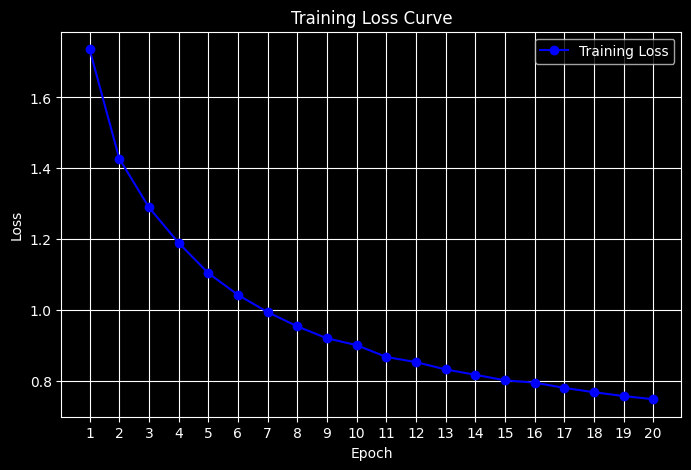

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), epoch_losses, marker="o", color="b", label="Training Loss")

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, num_epochs+1))
plt.grid()
plt.legend()

plt.show()


## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 70%, great work! 
This is a hard task to exceed 70% on.

If your accuracy is under 45%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [7]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for data,targets in testloader:

        output = model(data)
        _,predicted  =  torch.max(output.data, 1)
        total += targets.size(0)

        correct+=(predicted == targets).sum().item()

accuracy = 100 * correct / total
print(f"The test accuracy is {accuracy:.2f}%")

The test accuracy is 75.98%


## Saving your model
Using `torch.save`, save your model for future loading.

In [8]:
import os
current_folder = os.getcwd()
MODEL_PATH = os.path.join(current_folder, "cifar10_cnn_model.pth")

torch.save(model.state_dict(), MODEL_PATH)

## Make a Recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below.

I recommend that we build our own model rather than purchasing the algorithm from Detectocorp. The model I trained achieved 75.98% test accuracy, outperforming Detectocorp's algorithm by 5.98%. Our solution utilizes a custom CNN architecture consisting of three convolution layers and three fully connected layers, incorporating Dropout and MaxPool layers to prevent overfitting.

For training, I applied data augmentations like `RandomHorizontalFlip` and `RandomCrop`, optimized the network using the Adam optimizer with a learning rate of 0.001 and CrossEntropyLoss over 20 epochs with a batch size of 128.

While our model's accuracy does not yet match SOTA models listed in the notebook, it is important to note that those models are quite large and incredibly expensive to train. Given our current requirements, building and iterating on our own model is the most cost-effective and scalable path forward. Therefore, I strongly recommend an in-house build over purchasing.